In [1]:
import pypsa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution
ERROR 1: PROJ: proj_create_from_database: Open of /home/lukas/micromamba/envs/pypsa-eur/share/proj failed


In [2]:
historical_capacities = {
    "solar": {
        2020: 161.1,  # GW (IRENA RE Capacity Statistics 2021; Europe solar PV in 2020)
        2025: 430.0,  # GW (EC / SolarPower Europe figure for EU solar capacity in 2025)
        2030: 705.,   # TYNDP 2024 + FES 2025
        2035: 950.,   # TYNDP 2024 + FES 2025
    },
    "onwind": {
        2020: 194.0,  # GW (WindEurope: Europe onshore wind installed capacity, end-2020)
        2025: 254.0,  # GW (WindEurope: Europe onshore wind installed capacity, 2025)
        2030: 395.,   # TYNDP 2024 + FES 2025
        2035: 485.,   # TYNDP 2024 + FES 2025
    },
    "offwind": {
        2020: 25.0,   # GW (WindEurope: Europe offshore wind installed capacity, end-2020)
        2025: 37.0,   # GW (WindEurope: Europe offshore wind installed capacity, 2025)
        2030: 145.,   # TYNDP 2024 + FES 2025
        2035: 250.,   # TYNDP 2024 + FES 2025
    },
    "home battery": {
        2020: None,   # GW (not pinned in the numbers above)
        2025: 44.8,   # GW (Europe operating battery storage power capacity, 2025)
    },
    # optional alternative battery definition (grid-scale only)
    "battery": {
        2020: None,   # GW (not pinned in the numbers above)
        2025: 17.4,   # GW (Europe grid-scale battery power capacity, end-2025)
        2030: 46.,   # GW (Europe grid-scale battery power capacity, end-2025)
        2035: 140.,   # GW (Europe grid-scale battery power capacity, end-2025)
    },
    "industry gas": {
        2025: 1204,   # TWh
        2030: 888 + 160 + 65 + 12.,   # TWh
        2035: 750 + 115 + 75 + 90,   # TWh
    },
    "gas boiler": {
        2025: 1504,   # TWh
        2030: 990 + 300 + 12,   # TWh
        2035: 800 + 230 + 9,   # TWh
    },
}

In [3]:
n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2035_NT_3000.nc'
    )

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2035_NT_3000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [4]:
def get_model_capacity(n, carrier):
    covered = ['solar', 'onwind', 'offwind', 'battery', 'industry gas', 'gas boiler']
    assert carrier in covered, f"Carrier {carrier} not in covered,\ncovered: {covered}"

    if isinstance(n, str):
        n = pypsa.Network(n)

    if carrier == 'solar':
        return n.generators.loc[n.generators.carrier.isin(['solar', 'solar-hsat']), 'p_nom_opt'].sum() / 1e3 # to GW

    elif carrier == 'onwind':
        return n.generators.loc[n.generators.carrier.isin(['onwind']), 'p_nom_opt'].sum() / 1e3 # to GW

    elif carrier == 'offwind':
        return n.generators.loc[n.generators.carrier.isin(['offwind-ac', 'offwind-dc', 'offwind-float']), 'p_nom_opt'].sum() / 1e3 # to GW

    elif carrier == 'battery':
        return n.links.loc[n.links.carrier.isin(['battery charger']), 'p_nom_opt'].sum() / 1e3 # to GW

    elif carrier == 'industry gas':
        cs = ['heat100-200 industry gas', 'heat200-500 industry gas', 'heat>500 industry gas']
        l = n.links.index[n.links.carrier.isin(cs)]
        
        return n.links_t.p0.loc[:, l].mul(n.snapshot_weightings.objective, axis=0).sum().sum() / 1e6

    elif carrier == 'gas boiler':
        l = n.links.index[n.links.carrier.str.contains('gas boiler')]
        return n.links_t.p0.loc[:, l].sum(axis=1).mul(n.snapshot_weightings['generators']).sum() / 1e6


get_model_capacity(n, 'gas boiler')

1014.0774965566004

In [5]:
countries = [
    "AT", "BE", "BG", "HR", "CY", "CZ", "DK", "EE", "FI", "FR", "DE", "GR", "HU",
    "IE", "IT", "LV", "LT", "LU", "MT", "NL", "PL", "PT", "RO", "SK", "SI", "ES", "SE",
    "GB", "NO", "CH", "ME", "XK", "AL", "MK", "BA", "RS"
]

def get_industry_gas_consumption(n):
    
    fixed_demand = n.loads.loc[n.loads.carrier.isin(['gas for industry', 'gas for industry CC']), ['p_set']]

    fixed_demand = fixed_demand.loc[fixed_demand.index.str.startswith(tuple(countries))]
    w = n.snapshot_weightings['generators']

    fixed_demand = w.sum() * fixed_demand.sum()
    print('Warning! Does not yet consider gas boilers in industry')

    ls = n.links.index[
            n.links.carrier.isin(['SMR', 'SMR CC']) &
            n.links.index.str.startswith(tuple(countries))
        ]
    
    varying_demand = n.links_t.p0.loc[:, ls].sum(axis=1).mul(w, axis=0).sum() / 1e6

    return fixed_demand.sum() / 1e6 + varying_demand

get_industry_gas_consumption(n)

Warning! Does not yet consider gas boilers in industry


838.7459096021788

In [6]:
cs = ['heat100-200 industry gas', 'heat200-500 industry gas', 'heat>500 industry gas']
n.links.loc[n.links.carrier.isin(cs), 'p_nom_opt']

Link
AL0 0 heat100-200 industry gas      0.012707
AT0 0 heat100-200 industry gas      0.019410
BA0 0 heat100-200 industry gas      0.011772
BE0 0 heat100-200 industry gas      0.012004
BG0 0 heat100-200 industry gas      0.012650
                                     ...    
RS0 0 heat>500 industry gas        67.669097
SE1 0 heat>500 industry gas       253.792140
SI0 0 heat>500 industry gas       169.302249
SK0 0 heat>500 industry gas       381.693511
XK0 0 heat>500 industry gas        12.828638
Name: p_nom_opt, Length: 150, dtype: float64

In [7]:
colors = {
    'solar': 'gold',
    'onwind': '#235ebc',
    'offwind': '#74c6f2',
    'battery': '#ace37f',
    'industry gas': '#6d00fc',
    'gas boiler': '#db6a25',
    1500: '#000000',
    2000: '#330000',
    2500: '#660000',
    3000: '#990000',
    3500: '#cc0000',
    4000: '#ff0000',
}

In [8]:
def darken_color(color, factor=0.7):
    rgb = mcolors.to_rgb(color)
    return tuple(c * factor for c in rgb)

In [9]:
def plot_line_with_slope(ax, x1, y1, x2, y2, color, position='bottom', unit='GW'):
    """
    Plot a line between two points and display the slope.
    
    Parameters:
    -----------
    ax : matplotlib axis
        The axis to plot on
    x1, y1 : float
        Coordinates of the first point
    x2, y2 : float
        Coordinates of the second point
    color : str or tuple
        Color for the line
    position : str
        Position of the text label: 'bottom', 'center', or 'top'
    """
    # Plot the line
    ax.plot(
        [x1, x2], 
        [y1, y2], 
        color=color, 
        linestyle='-', 
        linewidth=2,
        alpha=0.7,
        zorder=0
    )
    
    # Calculate slope
    slope = (y2 - y1) / (x2 - x1)
    mid_x = (x1 + x2) / 2
    mid_y = (y1 + y2) / 2
    
    # Set vertical alignment based on position
    if position == 'bottom':
        va = 'top'
        text_y = mid_y
    elif position == 'center':
        va = 'center'
        text_y = mid_y
    elif position == 'top':
        va = 'bottom'
        text_y = mid_y
    else:
        raise ValueError("position must be 'bottom', 'center', or 'top'")
    
    # Display the slope
    ax.text(
        mid_x, 
        text_y,
        f'{int(slope)} {unit}/y', 
        color='k', 
        fontsize=10, 
        verticalalignment=va, 
        horizontalalignment='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='k', alpha=0.9)
    )


In [10]:
model_caps = {}

# for gas_limit in [1000, 1500, 2000, 2600, 3000]:
for gas_limit in [1500, 2000, 2500, 3000, 3500, 4000]:
    model_caps[gas_limit] = {}
    n = pypsa.Network(
        Path.cwd().parent / 'results' / 'networks' / f'base_s_50__3H-T-H-B-I-A-dist1_2035_NT_{gas_limit}.nc'
    )
    for carrier in ['solar', 'onwind', 'offwind', 'battery', 'industry gas', 'gas boiler']:
        model_caps[gas_limit][carrier] = get_model_capacity(n, carrier)


INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_1500.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_2000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_2500.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_3000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_3500.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_4000.nc has buses, carriers, generators, global_constraints, lines

In [11]:
model_caps

{1500: {'solar': 968.013011910053,
  'onwind': 514.8521502281558,
  'offwind': 292.4373313643164,
  'battery': 60.36494257996717,
  'industry gas': 253.237008800906,
  'gas boiler': 350.00096986495004},
 2000: {'solar': 945.3599926220755,
  'onwind': 482.3015258354953,
  'offwind': 291.690596808071,
  'battery': 60.18463806527405,
  'industry gas': 399.37341361341487,
  'gas boiler': 712.1042232880843},
 2500: {'solar': 915.4254609965326,
  'onwind': 463.0629243985675,
  'offwind': 265.98266825270724,
  'battery': 60.18464007546871,
  'industry gas': 404.4720113504359,
  'gas boiler': 802.7744489513035},
 3000: {'solar': 879.1449841458317,
  'onwind': 424.84944078657287,
  'offwind': 243.25253209032005,
  'battery': 59.74157318341485,
  'industry gas': 425.34452247830785,
  'gas boiler': 996.4025642541841},
 3500: {'solar': 871.7072600047811,
  'onwind': 424.3679721466328,
  'offwind': 243.120620669097,
  'battery': 59.640583325696085,
  'industry gas': 425.36070779878474,
  'gas boile

In [12]:
upper_ylims = {
    'solar': 1009,
    'onwind': 555,
    'offwind': 322,
    'battery': 152.,
    'industry gas': 1260,
    'gas boiler': 1560,
}

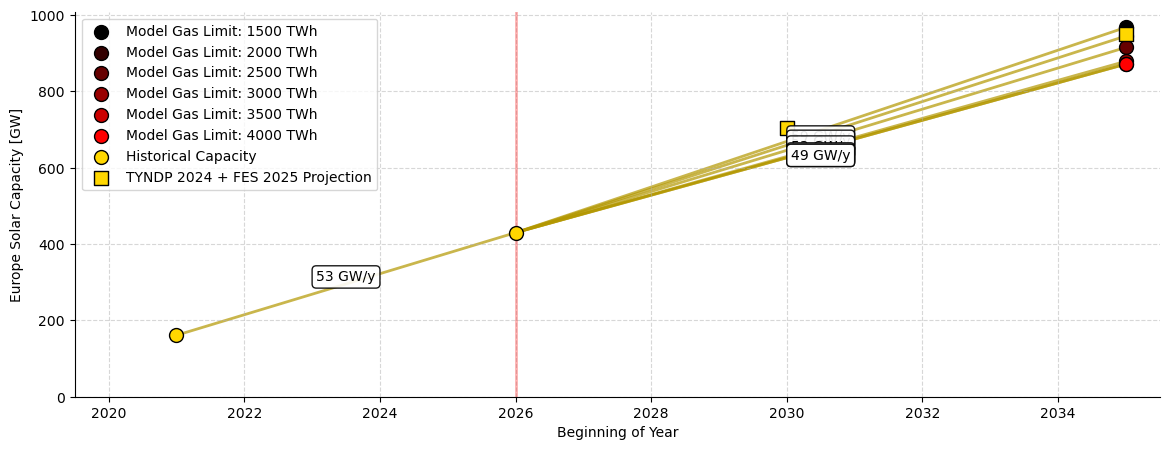

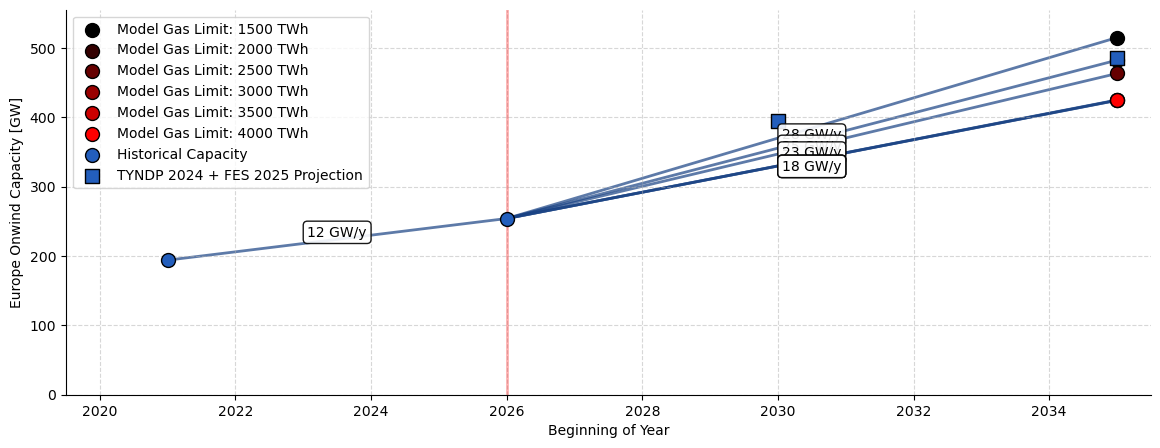

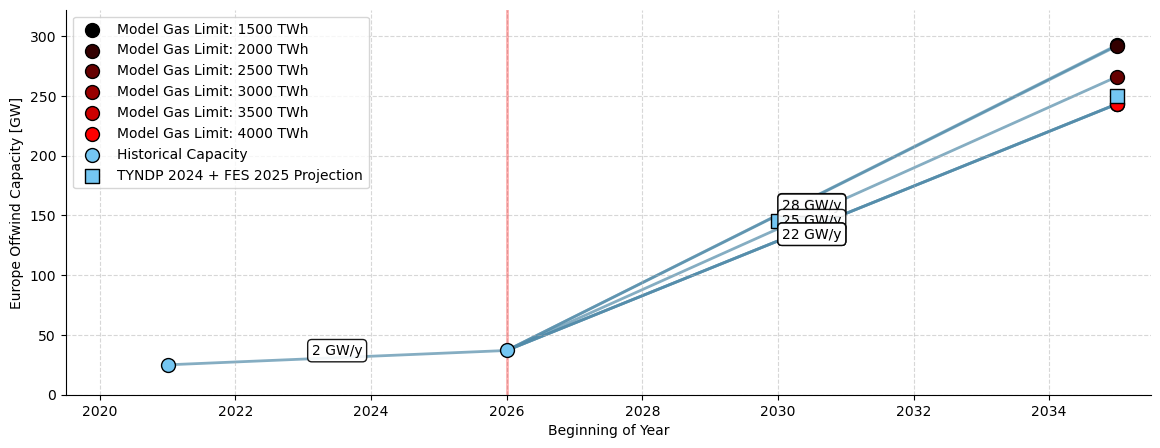

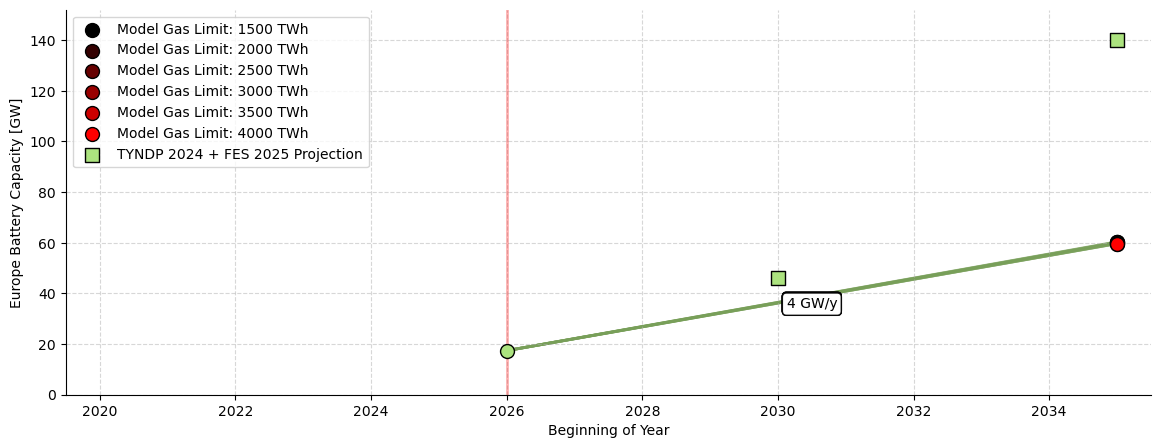

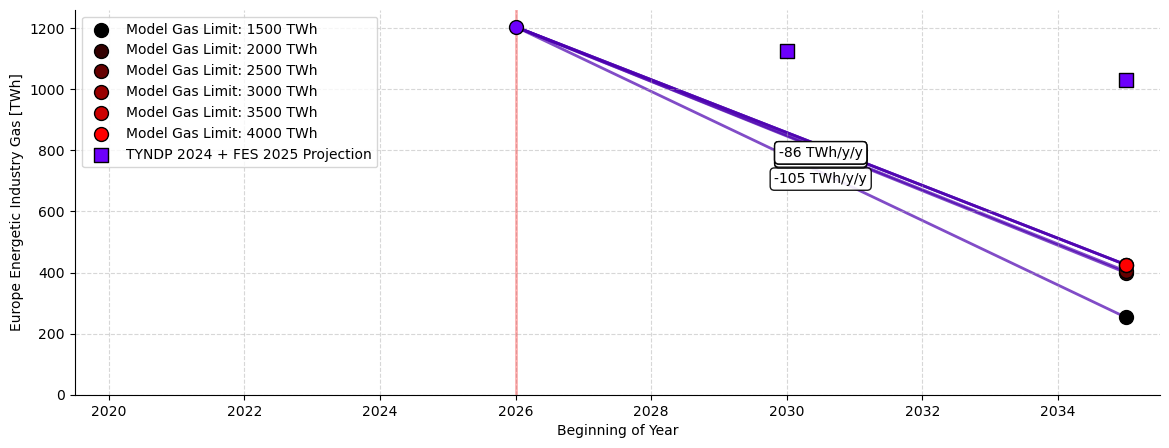

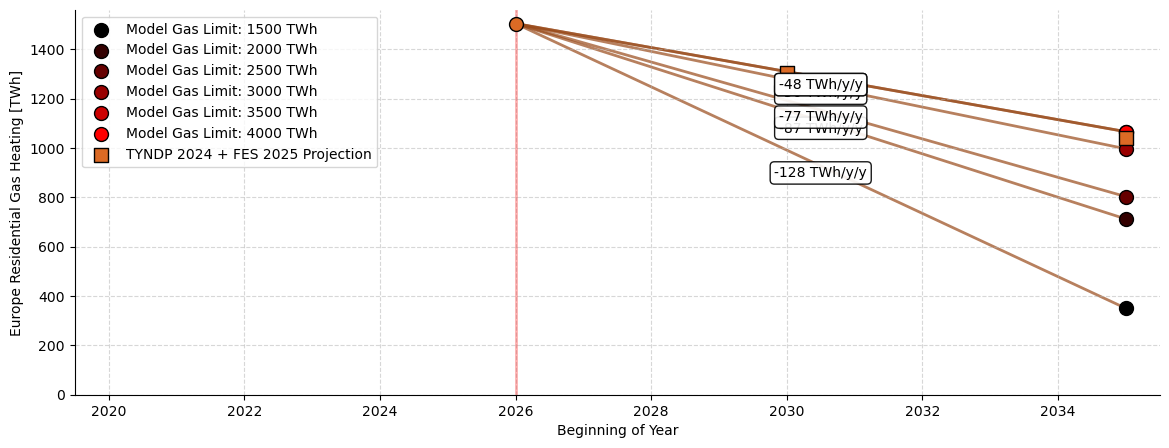

In [13]:
for carrier in ['solar', 'onwind', 'offwind', 'battery', 'industry gas', 'gas boiler']:

    fig, ax = plt.subplots(1, 1, figsize=(14, 5))
    ax.axvline(2026, color='r', linestyle='-', alpha=0.3, linewidth=2, zorder=1)
    ax.set_ylim(0, upper_ylims[carrier])

    color = colors[carrier]
    darkened_color = darken_color(color)

    scatter_kwargs = {
        'edgecolor': 'k',
        's': 100,
    }

    year = 2035
    for gas_limit in [1500, 2000, 2500, 3000, 3500, 4000]:

        cap = model_caps[gas_limit][carrier]

        ax.scatter(
            year, cap,  label=f'Model Gas Limit: {gas_limit} TWh', color=colors[gas_limit], **scatter_kwargs,
        )

        if carrier in ['industry gas', 'gas boiler']:
            unit = 'TWh/y'
        else:
            unit = 'GW'
    
        plot_line_with_slope(
            ax, 
            2026, historical_capacities[carrier][2025],
            2035, cap,
            darkened_color,
            position='bottom',
            unit=unit
        )

    if carrier in ['solar', 'onwind', 'offwind']:
        ax.scatter(
            2021, historical_capacities[carrier][2020], color=color, **scatter_kwargs, label=f'Historical Capacity'
        )
    
    ax.scatter(
        2026, historical_capacities[carrier][2025], color=color, **scatter_kwargs
    )
    ax.scatter(
        2030, historical_capacities[carrier][2030], color=color, marker='s', label='TYNDP 2024 + FES 2025 Projection', **scatter_kwargs
    )
    ax.scatter(
        2035, historical_capacities[carrier][2035], color=color, marker='s', **scatter_kwargs
    )

    if carrier in ['solar', 'onwind', 'offwind']:
        plot_line_with_slope(
            ax, 
            2021, historical_capacities[carrier][2020],
            2026, historical_capacities[carrier][2025],
            darkened_color,
            position='top'
        )

    ax.set_xlim(2019.5, 2035.5)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Beginning of Year')

    if carrier == 'industry gas':
        ax.set_ylabel(f'Europe Energetic Industry Gas [TWh]')
    elif carrier == 'gas boiler':
        ax.set_ylabel(f'Europe Residential Gas Heating [TWh]')
    else:
        ax.set_ylabel(f'Europe {carrier.capitalize()} Capacity [GW]')

    ax.grid(linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

    # ax.text(2026, 1, '2026', color='r', fontsize=10, verticalalignment='bottom', horizontalalignment='center')

    ax.legend(loc='upper left')

    plt.savefig(f'figs/{carrier}_phaseout.pdf')
    plt.show()

In [15]:
n.stores.carrier.unique()

array(['co2 stored', 'co2 sequestered', 'gas', 'H2 Store', 'battery',
       'EV battery', 'oil', 'ammonia store', 'methanol',
       'non-sequestered HVC', 'coal', 'home battery',
       'urban decentral heat vent'], dtype=object)

In [102]:
n.links.carrier.unique()

array(['DC', 'co2 sequestered', 'OCGT', 'CCGT', 'H2 Electrolysis',
       'gas pipeline', 'gas pipeline new', 'battery charger',
       'battery discharger', 'Sabatier', 'SMR CC', 'SMR', 'BEV charger',
       'V2G', 'oil refining', 'land transport oil',
       'urban central air heat pump', 'urban central gas boiler',
       'urban central gas CHP', 'urban central gas CHP CC',
       'unsustainable bioliquids', 'biogas to gas',
       'urban central solid biomass CHP',
       'urban central solid biomass CHP CC', 'biomass to liquid',
       'electrobiofuels', 'Haber-Bosch', 'ammonia cracker',
       'biomass-to-methanol', 'OCGT methanol',
       'heat100-200 industry solid biomass',
       'heat100-200 industry solid biomass CC',
       'heat100-200 industry gas', 'heat100-200 industry gas CC',
       'heat100-200 industry industrial heat pump high temperature',
       'heat100-200 industry electric boiler steam',
       'heat200-500 industry solid biomass',
       'heat200-500 industr

In [169]:
n.links.loc[n.links.carrier == 'battery charger'].head(30)[['bus0', 'bus1', 'p_nom_opt', 'p_nom', 'p_nom_extendable', 'p_max_pu', 'p_min_pu', 'capital_cost']]

,bus0,bus1,p_nom_opt,p_nom,p_nom_extendable,p_max_pu,p_min_pu,capital_cost
Link,,,,,,,,
AL0 0 battery charger,AL0 0,AL0 0 battery,0.000000,0.000000,True,1.0,0.0,33126.231898
AT0 0 battery charger,AT0 0,AT0 0 battery,27.181648,27.456210,True,1.0,0.0,33126.231898
BA0 0 battery charger,BA0 0,BA0 0 battery,0.000000,0.000000,True,1.0,0.0,33126.231898
BE0 0 battery charger,BE0 0,BE0 0 battery,274.712501,277.487375,True,1.0,0.0,33126.231898
BG0 0 battery charger,BG0 0,BG0 0 battery,1160.249694,1171.969388,True,1.0,0.0,33126.231898
CH0 0 battery charger,CH0 0,CH0 0 battery,0.000000,0.000000,True,1.0,0.0,33126.231898
CZ0 0 battery charger,CZ0 0,CZ0 0 battery,354.564483,358.145942,True,1.0,0.0,33126.231898
DE0 0 battery charger,DE0 0,DE0 0 battery,8514.819642,8600.827921,True,1.0,0.0,33126.231898
DE0 1 battery charger,DE0 1,DE0 1 battery,8514.819642,8600.827921,True,1.0,0.0,33126.231898


In [153]:
n.links.loc[n.links.carrier == 'battery discharger'].head(8)[['bus0', 'bus1', 'p_nom_opt', 'p_nom', 'p_nom_extendable', 'p_max_pu', 'p_min_pu', 'capital_cost', 'p_nom_min', 'p_nom_max']]

,bus0,bus1,p_nom_opt,p_nom,p_nom_extendable,p_max_pu,p_min_pu,capital_cost,p_nom_min,p_nom_max
Link,,,,,,,,,,
AL0 0 battery discharger,AL0 0 battery,AL0 0,0.000000,0.0,True,1.0,0.0,0.0,0.0,inf
AT0 0 battery discharger,AT0 0 battery,AT0 0,27.814682,0.0,True,1.0,0.0,0.0,0.0,inf
BA0 0 battery discharger,BA0 0 battery,BA0 0,0.000000,0.0,True,1.0,0.0,0.0,0.0,inf
BE0 0 battery discharger,BE0 0 battery,BE0 0,281.110286,0.0,True,1.0,0.0,0.0,0.0,inf
BG0 0 battery discharger,BG0 0 battery,BG0 0,1187.270773,0.0,True,1.0,0.0,0.0,0.0,inf
CH0 0 battery discharger,CH0 0 battery,CH0 0,0.000000,0.0,True,1.0,0.0,0.0,0.0,inf
CZ0 0 battery discharger,CZ0 0 battery,CZ0 0,362.821942,0.0,True,1.0,0.0,0.0,0.0,inf
DE0 0 battery discharger,DE0 0 battery,DE0 0,8713.121448,0.0,True,1.0,0.0,0.0,0.0,inf


In [150]:
n.stores.loc[n.stores.carrier == 'battery'].head()

,bus,type,carrier,e_nom,e_nom_mod,e_nom_extendable,e_nom_min,e_nom_max,e_min_pu,e_max_pu,...,marginal_cost,marginal_cost_quadratic,marginal_cost_storage,capital_cost,standing_loss,active,build_year,lifetime,e_nom_opt,location
Store,,,,,,,,,,,,,,,,,,,,,
AL0 0 battery,AL0 0 battery,,battery,0.000000,0.0,True,0.000000,0.000000,0.0,1.0,...,0.010085,0.0,0.0,17805.062352,0.0,True,0,22.5,0.000000,
AT0 0 battery,AT0 0 battery,,battery,109.824839,0.0,True,108.726590,110.923087,0.0,1.0,...,0.009134,0.0,0.0,17805.062352,0.0,True,0,22.5,108.726590,
BA0 0 battery,BA0 0 battery,,battery,0.000000,0.0,True,0.000000,0.000000,0.0,1.0,...,0.010307,0.0,0.0,17805.062352,0.0,True,0,22.5,0.000000,
BE0 0 battery,BE0 0 battery,,battery,1109.949501,0.0,True,1098.850006,1121.048996,0.0,1.0,...,0.010992,0.0,0.0,17805.062352,0.0,True,0,22.5,1098.850006,
BG0 0 battery,BG0 0 battery,,battery,4687.877552,0.0,True,4640.998777,4734.756328,0.0,1.0,...,0.010539,0.0,0.0,17805.062352,0.0,True,0,22.5,4640.998777,


In [170]:
n.generators.loc[n.generators.carrier == 'onwind', ['p_nom_extendable', 'p_nom_min', 'p_nom_max']].head()

,p_nom_extendable,p_nom_min,p_nom_max
Generator,,,
AL0 0 0 onwind,True,435.783881,444.587596
AT0 0 0 onwind,True,12380.224886,12630.330439
BA0 0 0 onwind,True,1140.565267,1163.606989
BE0 0 0 onwind,True,6315.376600,6442.959966
BG0 0 0 onwind,True,1366.281509,1393.883156


<Axes: xlabel='snapshot'>

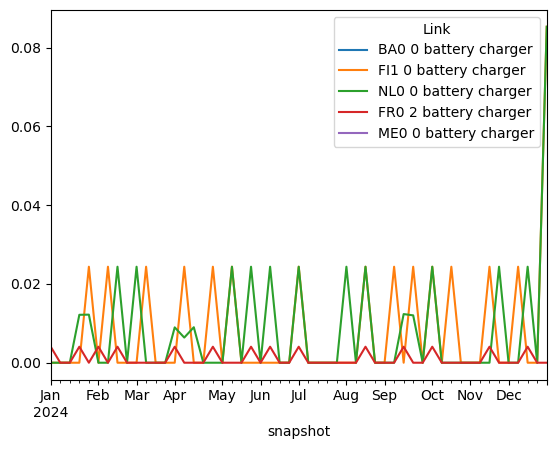

In [165]:
c = n.links.index[n.links.carrier == 'battery charger']
n.links_t.p0.loc[:, c].div(n.links.loc[c, 'p_nom_opt']).sample(5, axis=1).plot()

In [173]:
bat = pd.read_csv(
    Path.cwd().parent / 'resources' / 'tyndp_capacities_2035.csv', index_col=0, header=[0, 1]
)

In [179]:
bat.loc[:, ('battery', 'NT')]

AL         0.000000
AT       109.335106
BA         0.000000
BE      1105.000000
BG      4666.973309
CH         0.000000
CY      1182.000000
CZ      1426.195573
DE     34249.900000
DK      1829.841102
EE         0.000000
ES     15500.000000
FI      2214.276393
FR     10777.000000
GB      5162.792993
GR     22425.000000
HR       543.000000
HU       897.207816
IE     23608.615272
IT    110773.200000
LT      3200.000000
LU        11.272709
LV       144.159785
ME         0.000000
MK         0.000000
MT         0.000000
NL     19691.126530
NO         0.000000
PL         0.000000
PT      3082.982338
RO      1023.486446
RS         0.000000
SE         0.000000
SI         0.000000
SK      1445.850000
Name: (battery, NT), dtype: float64

In [181]:
de = c[c.str.startswith('DE')]
n.links.loc[de, 'p_nom_opt'].sum()

51088.91784905999

In [188]:
n = pypsa.Network(Path.cwd().parent / 'resources/networks/base_s_50__168H-T-H-B-I-A-dist1_2035_NT_2000.nc')
print(de)
n.links.loc[de, ['p_nom', 'p_nom_opt', 'p_nom_min', 'p_nom_max']]

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2035_NT_2000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


Index(['DE0 0 battery charger', 'DE0 1 battery charger',
       'DE0 2 battery charger', 'DE0 3 battery charger',
       'DE0 4 battery charger', 'DE0 5 battery charger'],
      dtype='object', name='Link')


,p_nom,p_nom_opt,p_nom_min,p_nom_max
Link,,,,
DE0 0 battery charger,1433.47132,0.0,1290.124188,1576.818452
DE0 1 battery charger,1433.47132,0.0,1290.124188,1576.818452
DE0 2 battery charger,1433.47132,0.0,1290.124188,1576.818452
DE0 3 battery charger,1433.47132,0.0,1290.124188,1576.818452
DE0 4 battery charger,1433.47132,0.0,1290.124188,1576.818452
DE0 5 battery charger,1433.47132,0.0,1290.124188,1576.818452


In [112]:
l = n.links.index[n.links.carrier == 'urban decentral air heat pump']
n.links_t.p0.loc[:, l].mean().div(n.links.loc[l, 'p_nom_opt']).sort_values()

Link
ES6 0 urban decentral air heat pump    0.393529
IT4 0 urban decentral air heat pump    0.470192
DE0 5 urban decentral air heat pump    0.531201
GR0 0 urban decentral air heat pump    0.537573
DE0 2 urban decentral air heat pump    0.542716
DE0 0 urban decentral air heat pump    0.547949
LU0 0 urban decentral air heat pump    0.550985
BE0 0 urban decentral air heat pump    0.558710
PT0 0 urban decentral air heat pump    0.563856
FR0 3 urban decentral air heat pump    0.574390
IE3 0 urban decentral air heat pump    0.585647
FR0 0 urban decentral air heat pump    0.585850
DK1 0 urban decentral air heat pump    0.593484
IT0 0 urban decentral air heat pump    0.620639
DE0 1 urban decentral air heat pump    0.637735
FR0 2 urban decentral air heat pump    0.647011
IT0 1 urban decentral air heat pump    0.649195
FR0 4 urban decentral air heat pump    0.667532
DE0 3 urban decentral air heat pump    0.672723
FR0 1 urban decentral air heat pump    0.679301
DK0 0 urban decentral air heat pump